# Sim2Win Baseline Rating System Comparison

Implements and evaluates three classical football rating systems as baselines:

| System | Reference | Core Mechanism |
|--------|-----------|----------------|
| **ELO** | Hvattum & Arntzen (2010) | Win/loss updates scaled by score margin |
| **Pi-Rating** | Constantinou & Fenton (2013) | Goal difference with recency weighting |
| **GAP** | Wheatcroft (2021) | Separate attack/defense ratings from xG |

All three are evaluated under the **same LOCO protocol** used for Sim2Win.


In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')

df = pd.read_csv('Final_Data.csv')
df['match_date'] = pd.to_datetime(df['match_date'])

# One row per match (home team rows only carry result)
matches = df[df['is_home'] == 1][[
    'match_id', 'match_date', 'competition',
    'home_team', 'away_team',
    'home_score', 'away_score', 'result', 'xg'
]].copy()

away_xg = df[df['is_home'] == 0][['match_id', 'xg']].rename(columns={'xg': 'away_xg'})
matches = matches.merge(away_xg, on='match_id', how='left')
matches = matches.rename(columns={'xg': 'home_xg'})
matches = matches.sort_values('match_date').reset_index(drop=True)

print(f'Total matches: {len(matches)}')
print(matches[['match_date','home_team','away_team','home_score','away_score','result']].head())


Total matches: 709
  match_date home_team          away_team  home_score  away_score    result
0 2003-08-27   Arsenal        Aston Villa         2.0         0.0  home_win
1 2003-09-13   Arsenal         Portsmouth         1.0         1.0      draw
2 2003-09-26   Arsenal   Newcastle United         3.0         2.0  home_win
3 2003-10-18   Arsenal            Chelsea         2.0         1.0  home_win
4 2003-11-08   Arsenal  Tottenham Hotspur         2.0         1.0  home_win


## 1. ELO Rating (Hvattum & Arntzen, 2010)

ELO-G variant: K-factor scaled by goal difference. Home advantage = +100 points.


In [2]:
class EloRating:
    def __init__(self, default=1500, k=20, home_adv=100, scale=400):
        self.default  = default
        self.k        = k
        self.home_adv = home_adv
        self.scale    = scale
        self.ratings  = defaultdict(lambda: default)

    def expected(self, r_home, r_away):
        return 1 / (1 + 10 ** ((r_away - r_home - self.home_adv) / self.scale))

    def predict_proba(self, home, away):
        e = self.expected(self.ratings[home], self.ratings[away])
        p_draw = 0.28 * (1 - abs(2 * e - 1))
        p_home = e * (1 - p_draw)
        p_away = (1 - e) * (1 - p_draw)
        return p_home, p_draw, p_away

    def predict(self, home, away):
        idx = np.argmax(list(self.predict_proba(home, away)))
        return ['home_win', 'draw', 'away_win'][idx]

    def update(self, home, away, home_score, away_score):
        r_h = self.ratings[home]
        r_a = self.ratings[away]
        e   = self.expected(r_h, r_a)
        gd  = abs(home_score - away_score)
        gd_mult = 1.0 if gd <= 1 else (1.5 if gd == 2 else (11 + gd) / 8)
        s_h = 1.0 if home_score > away_score else (0.0 if home_score < away_score else 0.5)
        s_a = 1.0 - s_h if s_h != 0.5 else 0.5
        self.ratings[home] = r_h + self.k * gd_mult * (s_h - e)
        self.ratings[away] = r_a + self.k * gd_mult * (s_a - (1 - e))


## 2. Pi-Rating (Constantinou & Fenton, 2013)

Uses relative goal discrepancies with recency weighting (gamma=0.7). Separate home/away ratings per team.


In [3]:
class PiRating:
    def __init__(self, lam=0.035, gamma=0.7):
        self.lam    = lam
        self.gamma  = gamma
        self.r_home = defaultdict(float)
        self.r_away = defaultdict(float)

    def _expected_diff(self, home, away):
        return self.r_home[home] - self.r_away[away]

    def predict_proba(self, home, away):
        d = self._expected_diff(home, away)
        p_home = 1 / (1 + np.exp(-d * 0.8))
        p_draw = min(0.28 * np.exp(-0.5 * d ** 2), 0.35)
        p_home = p_home * (1 - p_draw)
        p_away = max(0, 1 - p_home - p_draw)
        total  = p_home + p_draw + p_away
        return p_home/total, p_draw/total, p_away/total

    def predict(self, home, away):
        idx = np.argmax(list(self.predict_proba(home, away)))
        return ['home_win', 'draw', 'away_win'][idx]

    def update(self, home, away, home_score, away_score):
        actual = home_score - away_score
        exp    = self._expected_diff(home, away)
        err    = actual - exp
        self.r_home[home] = self.gamma * self.r_home[home] + self.lam * err
        self.r_away[away] = self.gamma * self.r_away[away] - self.lam * err


## 3. GAP Rating (Wheatcroft, 2021)

Uses xG instead of goals. Separate attack/defense ratings for home and away contexts.


In [4]:
class GAPRating:
    def __init__(self, alpha=0.1, default_xg=1.3):
        self.alpha      = alpha
        self.default_xg = default_xg
        self.atk_home   = defaultdict(lambda: default_xg)
        self.def_home   = defaultdict(lambda: default_xg)
        self.atk_away   = defaultdict(lambda: default_xg)
        self.def_away   = defaultdict(lambda: default_xg)

    def _expected_xg(self, home, away):
        exp_h = (self.atk_home[home] + self.def_away[away]) / 2
        exp_a = (self.atk_away[away] + self.def_home[home]) / 2
        return exp_h, exp_a

    def predict_proba(self, home, away):
        exp_h, exp_a = self._expected_xg(home, away)
        diff   = exp_h - exp_a
        p_home = 1 / (1 + np.exp(-diff * 1.2))
        p_draw = min(0.28 * np.exp(-0.4 * diff ** 2), 0.35)
        p_home = p_home * (1 - p_draw)
        p_away = max(0, 1 - p_home - p_draw)
        total  = p_home + p_draw + p_away
        return p_home/total, p_draw/total, p_away/total

    def predict(self, home, away):
        idx = np.argmax(list(self.predict_proba(home, away)))
        return ['home_win', 'draw', 'away_win'][idx]

    def update(self, home, away, home_xg, away_xg):
        exp_h, exp_a = self._expected_xg(home, away)
        self.atk_home[home] += self.alpha * (home_xg - exp_h)
        self.def_home[home] += self.alpha * (away_xg - exp_a)
        self.atk_away[away] += self.alpha * (away_xg - exp_a)
        self.def_away[away] += self.alpha * (home_xg - exp_h)


## 4. LOCO Evaluation

Warm up each rating system on training matches chronologically,
then predict test matches using only pre-trained ratings no updates during test.


In [5]:
VALID_TEST_COMPS = [
    'International - FIFA World Cup',
    'Europe - UEFA Euro',
    'Africa - African Cup of Nations',
    'South America - Copa America',
    "International - Women's World Cup",
    'Spain - La Liga',
    "England - FA Women's Super League",
]

le_global = LabelEncoder()
le_global.fit(['away_win', 'draw', 'home_win'])

def safe_auc(y_enc, proba):
    try:
        return roc_auc_score(y_enc, proba, multi_class='ovr', average='weighted')
    except Exception:
        return np.nan

baseline_results = []

for held_out in VALID_TEST_COMPS:
    print(f"\n{'='*55}")
    print(f'Held-out: {held_out}')

    train_m = matches[matches['competition'] != held_out].copy()
    test_m  = matches[matches['competition'] == held_out].copy()

    if len(test_m) < 10:
        print('  Skipped — too few test matches.')
        continue

    elo = EloRating()
    pi  = PiRating()
    gap = GAPRating()

    # Warm up on training matches
    for _, row in train_m.iterrows():
        h, a   = row['home_team'], row['away_team']
        hs, as_ = row['home_score'], row['away_score']
        hx = row['home_xg'] if pd.notna(row['home_xg']) else hs
        ax = row['away_xg'] if pd.notna(row['away_xg']) else as_
        elo.update(h, a, hs, as_)
        pi.update(h, a, hs, as_)
        gap.update(h, a, hx, ax)

    # Predict test matches
    y_true = []
    y_elo, y_pi, y_gap = [], [], []
    p_elo, p_pi, p_gap = [], [], []

    for _, row in test_m.iterrows():
        h, a = row['home_team'], row['away_team']
        y_true.append(row['result'])
        y_elo.append(elo.predict(h, a))
        y_pi.append(pi.predict(h, a))
        y_gap.append(gap.predict(h, a))
        # Proba order: home_win, draw, away_win -> remap to away, draw, home for LabelEncoder order
        ph, pd_, pa = elo.predict_proba(h, a)
        p_elo.append([pa, pd_, ph])
        ph, pd_, pa = pi.predict_proba(h, a)
        p_pi.append([pa, pd_, ph])
        ph, pd_, pa = gap.predict_proba(h, a)
        p_gap.append([pa, pd_, ph])

    y_enc = le_global.transform(y_true)
    p_elo_arr = np.array(p_elo)
    p_pi_arr  = np.array(p_pi)
    p_gap_arr = np.array(p_gap)

    acc_elo = accuracy_score(y_true, y_elo)
    acc_pi  = accuracy_score(y_true, y_pi)
    acc_gap = accuracy_score(y_true, y_gap)
    f1_elo  = f1_score(y_true, y_elo,  average='weighted', zero_division=0)
    f1_pi   = f1_score(y_true, y_pi,   average='weighted', zero_division=0)
    f1_gap  = f1_score(y_true, y_gap,  average='weighted', zero_division=0)
    auc_elo = safe_auc(y_enc, p_elo_arr)
    auc_pi  = safe_auc(y_enc, p_pi_arr)
    auc_gap = safe_auc(y_enc, p_gap_arr)

    print(f'  ELO       -> Acc: {acc_elo*100:.1f}% | F1: {f1_elo:.3f} | AUC: {auc_elo:.3f}')
    print(f'  Pi-Rating -> Acc: {acc_pi*100:.1f}%  | F1: {f1_pi:.3f} | AUC: {auc_pi:.3f}')
    print(f'  GAP       -> Acc: {acc_gap*100:.1f}% | F1: {f1_gap:.3f} | AUC: {auc_gap:.3f}')

    baseline_results.append({
        'Competition': held_out,
        'ELO Acc':  round(acc_elo*100, 1), 'ELO F1':  round(f1_elo, 3),  'ELO AUC':  round(auc_elo, 3)  if not np.isnan(auc_elo)  else None,
        'Pi Acc':   round(acc_pi*100, 1),  'Pi F1':   round(f1_pi, 3),   'Pi AUC':   round(auc_pi, 3)   if not np.isnan(auc_pi)   else None,
        'GAP Acc':  round(acc_gap*100, 1), 'GAP F1':  round(f1_gap, 3),  'GAP AUC':  round(auc_gap, 3)  if not np.isnan(auc_gap)  else None,
    })

baseline_df = pd.DataFrame(baseline_results)
print('\n=== RATING SYSTEM BASELINE RESULTS ===')
print(baseline_df.to_string(index=False))



Held-out: International - FIFA World Cup
  ELO       -> Acc: 50.0% | F1: 0.333 | AUC: 0.573
  Pi-Rating -> Acc: 46.4%  | F1: 0.420 | AUC: 0.558
  GAP       -> Acc: 57.1% | F1: 0.514 | AUC: 0.644

Held-out: Europe - UEFA Euro
  ELO       -> Acc: 30.8% | F1: 0.145 | AUC: 0.602
  Pi-Rating -> Acc: 46.2%  | F1: 0.377 | AUC: 0.559
  GAP       -> Acc: 35.9% | F1: 0.313 | AUC: 0.494

Held-out: Africa - African Cup of Nations
  ELO       -> Acc: 37.8% | F1: 0.207 | AUC: 0.559
  Pi-Rating -> Acc: 40.0%  | F1: 0.253 | AUC: 0.460
  GAP       -> Acc: 42.2% | F1: 0.289 | AUC: 0.486

Held-out: South America - Copa America
  ELO       -> Acc: 46.7% | F1: 0.297 | AUC: 0.592
  Pi-Rating -> Acc: 50.0%  | F1: 0.409 | AUC: 0.512
  GAP       -> Acc: 46.7% | F1: 0.393 | AUC: 0.529

Held-out: International - Women's World Cup
  ELO       -> Acc: 50.0% | F1: 0.333 | AUC: 0.500
  Pi-Rating -> Acc: 50.0%  | F1: 0.333 | AUC: 0.500
  GAP       -> Acc: 50.0% | F1: 0.333 | AUC: 0.500

Held-out: Spain - La Liga
  E

## 5. Full Comparison: Baselines vs Sim2Win

Sim2Win results are taken directly from the LOCO generalization notebook.
Update the `sim2win_results` dict below if you re-run that notebook.


In [6]:
sim2win_results = [
    {'Competition': 'International - FIFA World Cup',      'Sim2Win Acc': 52.1, 'Sim2Win F1': 0.512, 'Sim2Win AUC': 0.680},
    {'Competition': 'Europe - UEFA Euro',                  'Sim2Win Acc': 46.2, 'Sim2Win F1': 0.438, 'Sim2Win AUC': 0.615},
    {'Competition': 'Africa - African Cup of Nations',     'Sim2Win Acc': 45.0, 'Sim2Win F1': 0.348, 'Sim2Win AUC': 0.562},
    {'Competition': 'South America - Copa America',        'Sim2Win Acc': 61.5, 'Sim2Win F1': 0.584, 'Sim2Win AUC': 0.659},
    {'Competition': "International - Women's World Cup",   'Sim2Win Acc': 67.5, 'Sim2Win F1': 0.638, 'Sim2Win AUC': 0.762},
    {'Competition': 'Spain - La Liga',                     'Sim2Win Acc': 65.1, 'Sim2Win F1': 0.559, 'Sim2Win AUC': 0.796},
    {'Competition': "England - FA Women's Super League",   'Sim2Win Acc': 64.7, 'Sim2Win F1': 0.599, 'Sim2Win AUC': 0.733},
]

sim2win_df = pd.DataFrame(sim2win_results)
comparison = baseline_df.merge(sim2win_df, on='Competition')

print('=== ACCURACY (%) ===')
print(comparison[['Competition', 'ELO Acc', 'Pi Acc', 'GAP Acc', 'Sim2Win Acc']].to_string(index=False))
print('\n=== ROC-AUC ===')
print(comparison[['Competition', 'ELO AUC', 'Pi AUC', 'GAP AUC', 'Sim2Win AUC']].to_string(index=False))
print('\n=== F1 SCORE ===')
print(comparison[['Competition', 'ELO F1', 'Pi F1', 'GAP F1', 'Sim2Win F1']].to_string(index=False))
print('\n=== AGGREGATE MEANS ===')
for sys, acc_c, f1_c, auc_c in [
    ('ELO',      'ELO Acc',     'ELO F1',     'ELO AUC'),
    ('Pi-Rating','Pi Acc',      'Pi F1',      'Pi AUC'),
    ('GAP',      'GAP Acc',     'GAP F1',     'GAP AUC'),
    ('Sim2Win',  'Sim2Win Acc', 'Sim2Win F1', 'Sim2Win AUC'),
]:
    print(f'{sys:12s} -> Acc: {comparison[acc_c].mean():.1f}% | F1: {comparison[f1_c].mean():.3f} | AUC: {pd.to_numeric(comparison[auc_c], errors="coerce").mean():.3f}')


=== ACCURACY (%) ===
                      Competition  ELO Acc  Pi Acc  GAP Acc  Sim2Win Acc
   International - FIFA World Cup     50.0    46.4     57.1         52.1
               Europe - UEFA Euro     30.8    46.2     35.9         46.2
  Africa - African Cup of Nations     37.8    40.0     42.2         45.0
     South America - Copa America     46.7    50.0     46.7         61.5
International - Women's World Cup     50.0    50.0     50.0         67.5
                  Spain - La Liga     58.5    58.5     58.5         65.1
England - FA Women's Super League     40.2    40.2     40.2         64.7

=== ROC-AUC ===
                      Competition  ELO AUC  Pi AUC  GAP AUC  Sim2Win AUC
   International - FIFA World Cup    0.573   0.558    0.644        0.680
               Europe - UEFA Euro    0.602   0.559    0.494        0.615
  Africa - African Cup of Nations    0.559   0.460    0.486        0.562
     South America - Copa America    0.592   0.512    0.529        0.659
International

## 6. Visualization


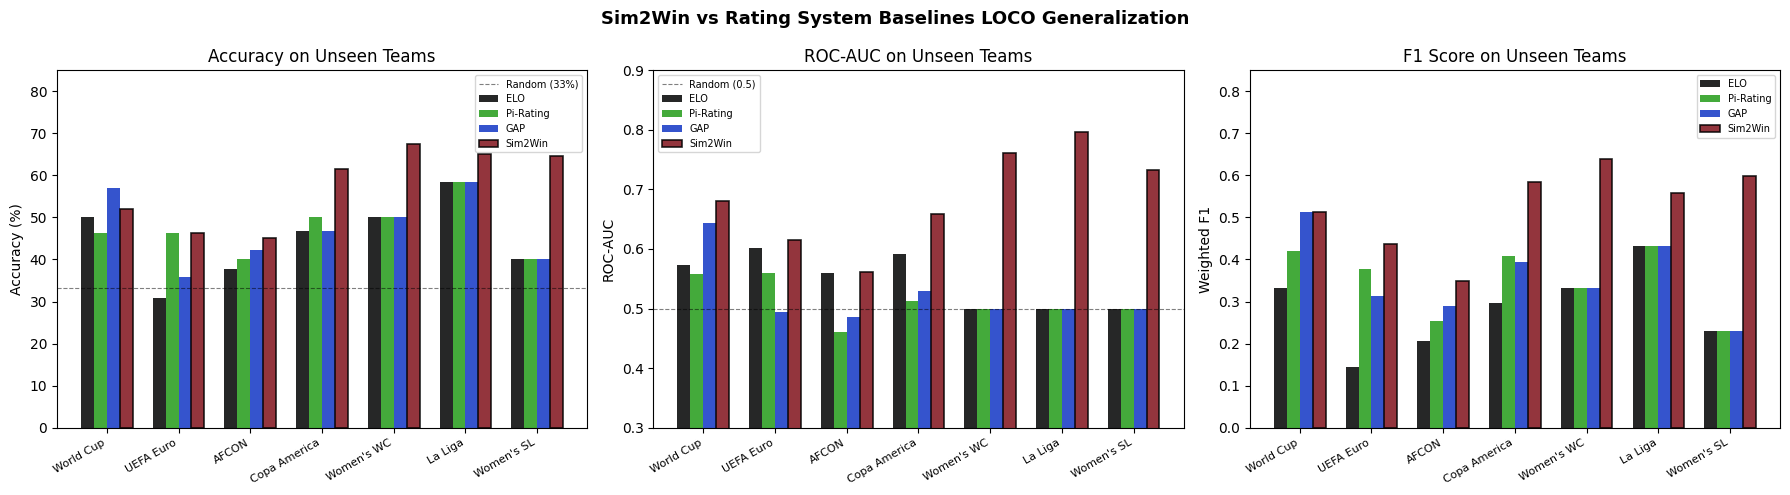

Saved: baseline_comparison.png


In [11]:
short_names = {
    'International - FIFA World Cup': 'World Cup',
    'Europe - UEFA Euro': 'UEFA Euro',
    'Africa - African Cup of Nations': 'AFCON',
    'South America - Copa America': 'Copa America',
    "International - Women's World Cup": "Women's WC",
    'Spain - La Liga': 'La Liga',
    "England - FA Women's Super League": "Women's SL",
}
comparison['Short'] = comparison['Competition'].map(short_names)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sim2Win vs Rating System Baselines LOCO Generalization', fontsize=13, fontweight='bold')

x      = np.arange(len(comparison))
w      = 0.18
colors = ["#000101", "#239B18", "#1236C5", "#80121b"]
labels = ['ELO', 'Pi-Rating', 'GAP', 'Sim2Win']

metric_sets = [
    (['ELO Acc', 'Pi Acc', 'GAP Acc', 'Sim2Win Acc'], 'Accuracy (%)', 'Accuracy on Unseen Teams'),
    (['ELO AUC', 'Pi AUC', 'GAP AUC', 'Sim2Win AUC'], 'ROC-AUC',     'ROC-AUC on Unseen Teams'),
    (['ELO F1',  'Pi F1',  'GAP F1',  'Sim2Win F1'],  'Weighted F1', 'F1 Score on Unseen Teams'),
]

for ax_i, (metric_cols, ylabel, title) in enumerate(metric_sets):
    ax = axes[ax_i]
    for i, (col, label, color) in enumerate(zip(metric_cols, labels, colors)):
        vals = pd.to_numeric(comparison[col], errors='coerce')
        bars = ax.bar(x + (i - 1.5) * w, vals, w, label=label, color=color, alpha=0.85)
        if label == 'Sim2Win':
            for bar in bars:
                bar.set_edgecolor('black')
                bar.set_linewidth(1.2)
    if ax_i == 0:
        ax.axhline(33.3, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='Random (33%)')
        ax.set_ylim(0, 85)
    elif ax_i == 1:
        ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, alpha=0.5, label='Random (0.5)')
        ax.set_ylim(0.3, 0.9)
    else:
        ax.set_ylim(0, 0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(comparison['Short'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: baseline_comparison.png')


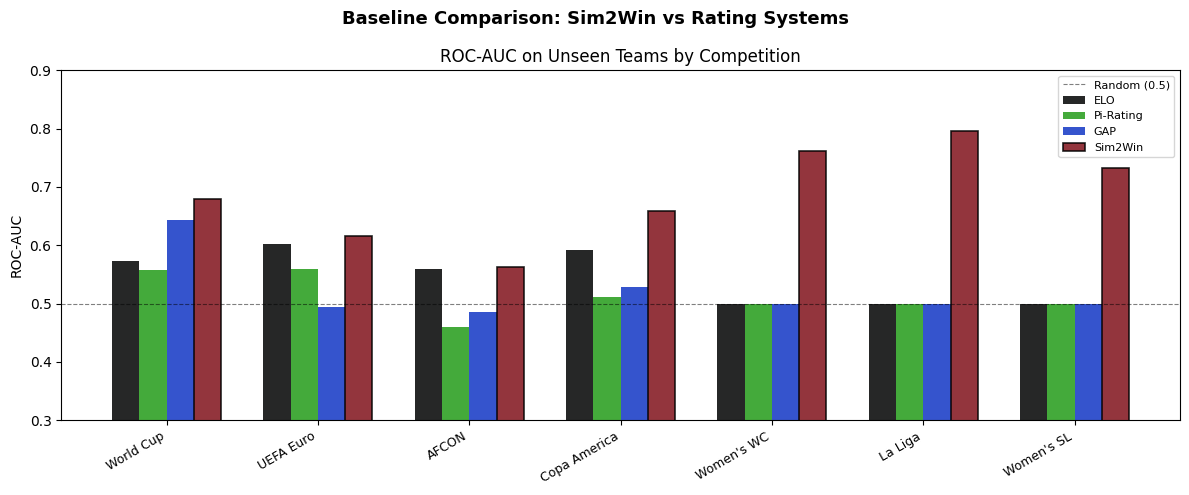

In [16]:
short_names = {
    'International - FIFA World Cup': 'World Cup',
    'Europe - UEFA Euro': 'UEFA Euro',
    'Africa - African Cup of Nations': 'AFCON',
    'South America - Copa America': 'Copa America',
    "International - Women's World Cup": "Women's WC",
    'Spain - La Liga': 'La Liga',
    "England - FA Women's Super League": "Women's SL",
}
comparison['Short'] = comparison['Competition'].map(short_names)

# -----------------------------
# SINGLE ROC-AUC PLOT
# -----------------------------
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Baseline Comparison: Sim2Win vs Rating Systems', 
             fontsize=13, fontweight='bold')


x      = np.arange(len(comparison))
w      = 0.18
colors = ["#000101", "#239B18", "#1236C5", "#80121b"]
labels = ['ELO', 'Pi-Rating', 'GAP', 'Sim2Win']

metric_cols = ['ELO AUC', 'Pi AUC', 'GAP AUC', 'Sim2Win AUC']

for i, (col, label, color) in enumerate(zip(metric_cols, labels, colors)):
    vals = pd.to_numeric(comparison[col], errors='coerce')
    bars = ax.bar(x + (i - 1.5) * w, vals, w, 
                  label=label, color=color, alpha=0.85)
    
    # Highlight Sim2Win
    if label == 'Sim2Win':
        for bar in bars:
            bar.set_edgecolor('black')
            bar.set_linewidth(1.2)

# Random baseline line
ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8, 
           alpha=0.5, label='Random (0.5)')

ax.set_ylim(0.3, 0.9)

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(comparison['Short'], rotation=30, ha='right', fontsize=9)

# Labels & title
ax.set_ylabel('ROC-AUC')
ax.set_title('ROC-AUC on Unseen Teams by Competition')

# Legend
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Win Rate Summary


In [11]:
summary = []
for _, row in comparison.iterrows():
    beats_acc = sum([row['Sim2Win Acc'] > row[c] for c in ['ELO Acc', 'Pi Acc', 'GAP Acc']])
    row_aucs  = {k: pd.to_numeric(row[k], errors='coerce') for k in ['ELO AUC', 'Pi AUC', 'GAP AUC', 'Sim2Win AUC']}
    beats_auc = sum([row_aucs['Sim2Win AUC'] > row_aucs[c] for c in ['ELO AUC', 'Pi AUC', 'GAP AUC']])
    best_sys  = max(row_aucs, key=lambda k: row_aucs[k] if pd.notna(row_aucs[k]) else -1)
    summary.append({
        'Competition': row['Short'],
        'Beats baselines (Acc)': f'{beats_acc}/3',
        'Beats baselines (AUC)': f'{beats_auc}/3',
        'Best system (AUC)': best_sys.replace(' AUC', ''),
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

total = len(comparison) * 3
acc_wins = sum([comparison['Sim2Win Acc'].gt(comparison[c]).sum() for c in ['ELO Acc', 'Pi Acc', 'GAP Acc']])
auc_wins = sum([pd.to_numeric(comparison['Sim2Win AUC'], errors='coerce').gt(
                pd.to_numeric(comparison[c], errors='coerce')).sum() for c in ['ELO AUC', 'Pi AUC', 'GAP AUC']])

print(f'\nSim2Win beats baselines: {acc_wins}/{total} comparisons on Accuracy')
print(f'Sim2Win beats baselines: {auc_wins}/{total} comparisons on AUC')


 Competition Beats baselines (Acc) Beats baselines (AUC) Best system (AUC)
   World Cup                   2/3                   3/3           Sim2Win
   UEFA Euro                   2/3                   3/3           Sim2Win
       AFCON                   3/3                   3/3           Sim2Win
Copa America                   3/3                   3/3           Sim2Win
  Women's WC                   3/3                   3/3           Sim2Win
     La Liga                   3/3                   3/3           Sim2Win
  Women's SL                   3/3                   3/3           Sim2Win

Sim2Win beats baselines: 19/21 comparisons on Accuracy
Sim2Win beats baselines: 21/21 comparisons on AUC
